## Aula 1 (25/08)
Começar com uma discretização baixa

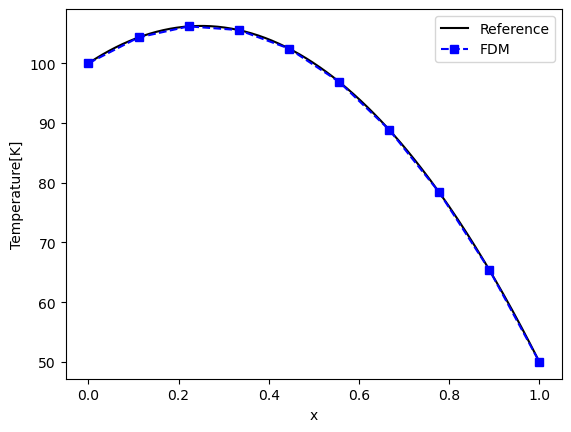

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#Example 1- FDM - 1D - Steady
#Input data
L = 1
s = 20
k = 0.1
T1bar = 100
T2bar = 50

#Discretization
N = 10
x = np.linspace(0, L, N)
dx = x[1] - x[0]

# Construção das matrizes
A = np.diag(np.ones(N) * 2)
A = A + np.diag(np.ones(N-1) * (-1), 1)
A = A + np.diag(np.ones(N-1) * (-1), -1) 
b = (s * dx**2/k) * np.ones(N)

# Boudary Conditions
A[0, :] = 0
A[0, 0] = 1
b[0] = T1bar

A[N-1, :] = 0
A[N-1, N-1] = 1
b[N-1] = T2bar

#Solving
T = np.linalg.solve(A,b)

#Reference Solution
xref = np.linspace(0, L, 200)
Tref = -s * xref**2/(2*k) + (T2bar - T1bar) * xref / L + s * L * xref / (2 * k) + T1bar

#Plotting the solution
plt.plot(xref, Tref, '-k' , label ='Reference')
plt.plot(x, T, '--sb', label='FDM')
plt.xlabel('x')
plt.ylabel('Temperature[K]')
plt.legend()
plt.show()

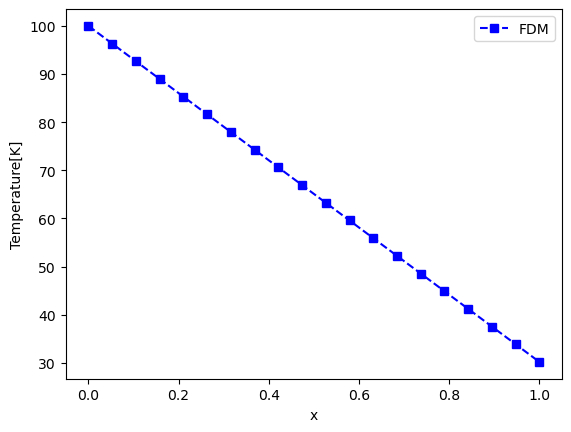

array([100.        ,  96.32621157,  92.65242314,  88.97863471,
        85.30484627,  81.63105784,  77.95726941,  74.28348098,
        70.60969255,  66.93590412,  63.26211569,  59.58832725,
        55.91453882,  52.24075039,  48.56696196,  44.89317353,
        41.2193851 ,  37.54559666,  33.87180823,  30.1980198 ])

In [ ]:

#Exercício 2
#Input data
L = 1
s = 0
k = 0.1
T1bar = 100
T2bar = 50
hc = 5
Tinf = 20

#Discretization
N = 20
x = np.linspace(0, L, N)
dx = x[1] - x[0]

# Construção das matrizes
A = np.diag(np.ones(N) * 2)
A = A + np.diag(np.ones(N-1) * (-1), 1)
A = A + np.diag(np.ones(N-1) * (-1), -1) 
b = (s * dx**2/k) * np.ones(N)

# Boudary Conditions
A[0, :] = 0
A[0, 0] = 1
b[0] = T1bar

A[N-1, :] = 0
A[N-1, N-1] = 1
b[N-1] = T2bar

# Formula do h
A[N-1, N-2] += -1
A[N-1, N-1] += 2 * hc * dx / k 
b[N-1] += 2 * hc * dx * Tinf / k

#Solving
T = np.linalg.solve(A,b)

#Reference Solution
xref = np.linspace(0, L, 200)
Tref = -s * (xref**2)/(2*k) + (T2bar - T1bar) * xref / L + s * L * xref / (2 * k) + T1bar

#Plotting the solution
plt.plot(x, T, '--sb', label='FDM')
plt.xlabel('x')
plt.ylabel('Temperature[K]')
plt.legend()
plt.show()
T


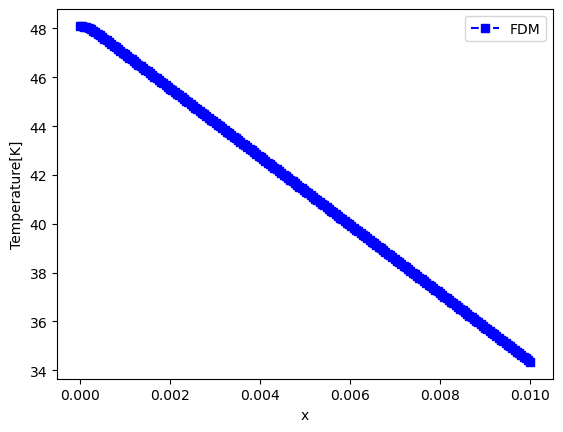

In [10]:
# Exemplo 3
#Input data
L = 10e-3
s0 = 1e6
sigma = 1e-7
k = 0.2
hc = 30
Tinf = 25

#Discretization
N = 200
x = np.linspace(0, L, N)
dx = x[1] - x[0]

# Construção das matrizes
A = np.diag(np.ones(N) * 2)
A = A + np.diag(np.ones(N-1) * (-1), 1)
A = A + np.diag(np.ones(N-1) * (-1), -1)
s = lambda x: s0 * np.exp(-x**2 / sigma) 
b = s(x) * dx**2/k

# Boudary Conditions
A[0, 1] += -1

# Formula do h
A[N-1, N-2] += -1
A[N-1, N-1] += 2 * hc * dx / k 
b[N-1] += 2 * hc * dx * Tinf / k

#Solving
T = np.linalg.solve(A,b)

#Plotting the solution
plt.plot(x, T, '--sb', label='FDM')
plt.xlabel('x')
plt.ylabel('Temperature[K]')
plt.legend()
plt.show()

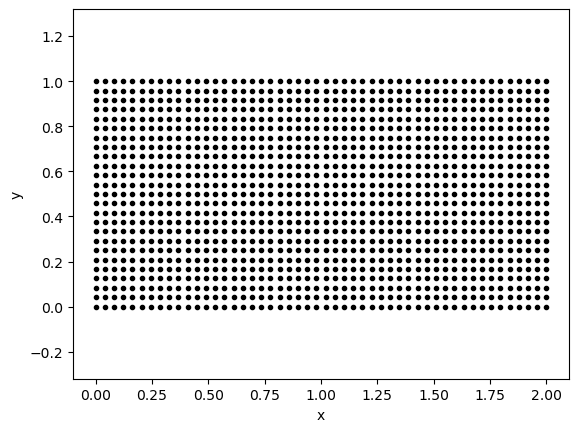

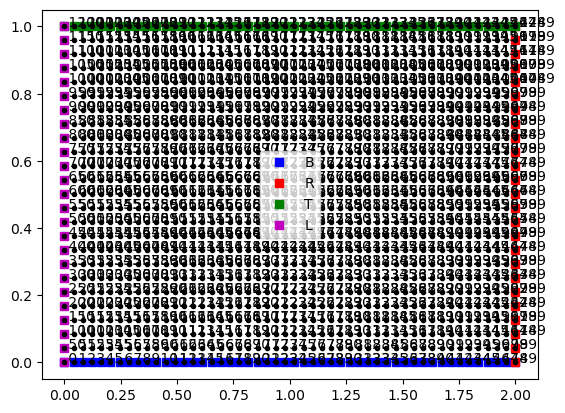

0.00362624


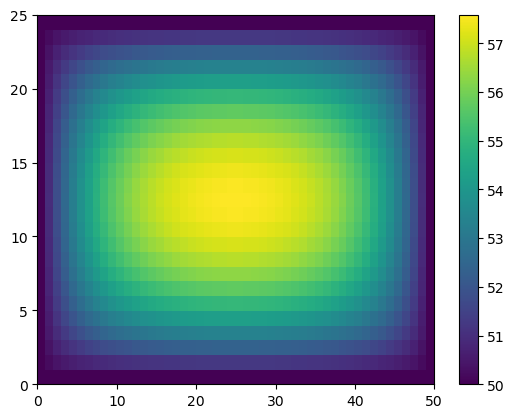

In [20]:
#Exemplo 4 (bi-dimensional)
import numpy as np
import matplotlib.pyplot as plt

#Input data
Lx = 2
Ly = 1
k = 0.3
s = 20
Tbar = 50

#Discretization
Nx = 50
Ny = 25
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[xg, yg] = np.meshgrid(x,y) # Generate a matrix from vectors x and y 
x = xg.flatten() # Verticaliza a matriz
y = yg.flatten()

plt.plot(x, y, '.k')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

# regions
region_B = np.arange(0, Nx, 1)
region_R = np.arange(Nx - 1, Nx * Ny, Nx)
region_T = np.arange(Nx * (Ny - 1), Nx * Ny, 1)
region_L = np.arange(0, Nx * (Ny - 1) + 1, Nx)

plt.plot(x[region_B], y[region_B], 'sb', label = 'B')
plt.plot(x[region_R], y[region_R], 'sr', label = 'R')
plt.plot(x[region_T], y[region_T], 'sg', label = 'T')
plt.plot(x[region_L], y[region_L], 'sm', label = 'L')
plt.plot(x, y, '.k')
plt.legend()
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.text(xi, yi, ' ' + str(i))
plt.show()

# Assembly of matrices and vectors
A = np.zeros((Nx * Ny, Nx * Ny))
b = np.zeros(Nx * Ny)

for i in range(Nx * Ny):
    if i in region_B:
        A[i, i] = 1
        b[i] = Tbar
    elif i in region_R:
        A[i, i] = 1
        b[i] = Tbar
    elif i in region_T:
        A[i, i] = 1
        b[i] = Tbar
    elif i in region_L:
        A[i, i] = 1
        b[i] = Tbar
    else:
        A[i, i - Nx] = -1 / dy**2
        A[i, i - 1] = -1 / dx**2
        A[i, i] = 2 / dx**2 + 2 / dy**2
        A[i, i + 1] = -1 / dx**2
        A[i, i + Nx] = -1 / dy**2
        b[i] = s / k   

# Solving
T = np.linalg.solve(A, b)
Tmatrix = T.reshape((Ny, Nx))

#Plotting
plt.figure()
plt.pcolor(Tmatrix)
plt.colorbar()

# Matrix sparsity
f = np.sum(np.abs(A) > np.finfo(float).eps) / (Nx * Ny)**2
print(f)

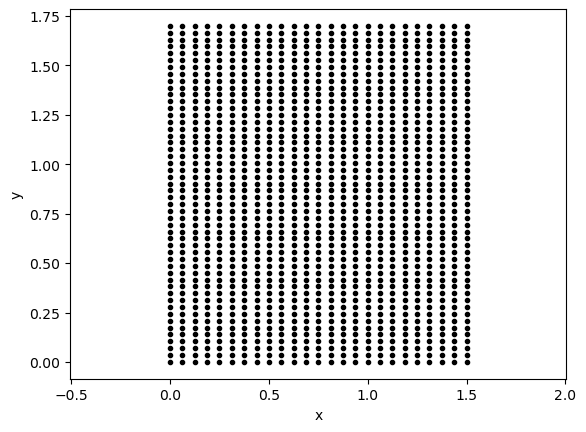

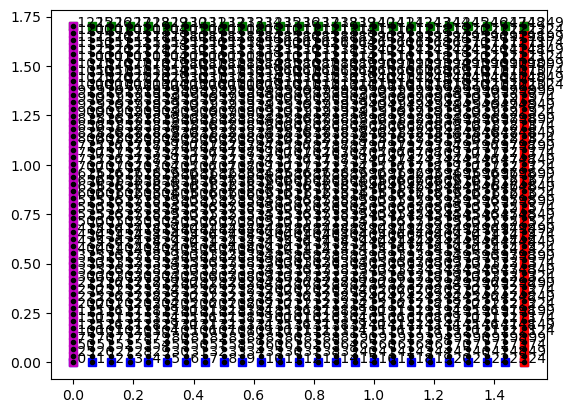

0.0037184


3.9595048690820156

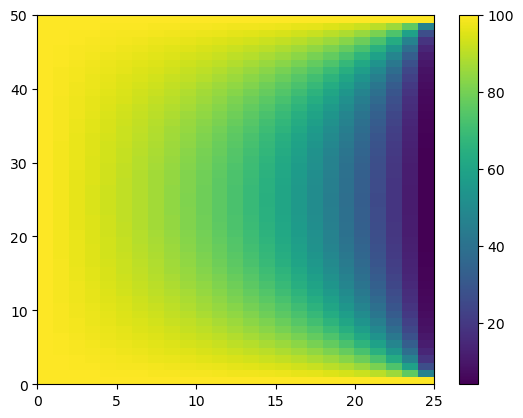

In [ ]:
# Exercício bi-dimensional
import numpy as np
import matplotlib.pyplot as plt

#Input data
Lx = 1.5
Ly = 1.7
k = 1
s = 0
Tbar = 100
h = 10
Tinf = 10

#Discretization
Nx = 25
Ny = 50
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[xg, yg] = np.meshgrid(x,y) # Generate a matrix from vectors x and y 
x = xg.flatten() # Verticaliza a matriz
y = yg.flatten()

plt.plot(x, y, '.k')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

# regions
region_B = np.arange(0, Nx, 1)
region_R = np.arange(Nx - 1, Nx * Ny, Nx)
region_T = np.arange(Nx * (Ny - 1), Nx * Ny, 1)
region_L = np.arange(0, Nx * (Ny - 1) + 1, Nx)

plt.plot(x[region_B], y[region_B], 'sb', label = 'B')
plt.plot(x[region_R], y[region_R], 'sr', label = 'R')
plt.plot(x[region_T], y[region_T], 'sg', label = 'T')
plt.plot(x[region_L], y[region_L], 'sm', label = 'L')
plt.plot(x, y, '.k')
#plt.legend()
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.text(xi, yi, ' ' + str(i))
plt.show()

# Assembly of matrices and vectors
A = np.zeros((Nx * Ny, Nx * Ny))
b = np.zeros(Nx * Ny)

for i in range (Nx * Ny):
    if i in region_B:
        A[i, i] = 1
        b[i] = Tbar
    elif i in region_T:
        A[i, i] = 1
        b[i] = Tbar
    elif i in region_L:
        A[i, i] = 1
        b[i] = Tbar
    elif i in region_R:
        A[i, i - Nx] = -1 / dy**2
        A[i, i - 1] = -2 / dx**2
        A[i, i] = 2 / dx**2 + 2 / dy**2 + 2 * hc / (dx * k)
        A[i, i + Nx] = -1 / dy**2
        b[i] = s / k
    else:
        A[i, i - Nx] = -1 / dy**2
        A[i, i - 1] = -1 / dx**2
        A[i, i] = 2 / dx**2 + 2 / dy**2
        A[i, i + 1] = -1 / dx**2
        A[i, i + Nx] = -1 / dy**2
        b[i] = s / k   

# Solving
T = np.linalg.solve(A, b)
Tmatrix = T.reshape((Ny, Nx))

#Plotting
plt.figure()
plt.pcolor(Tmatrix)
plt.colorbar()

# Matrix sparsity
f = np.sum(np.abs(A) > np.finfo(float).eps) / (Nx * Ny)**2
print(f)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


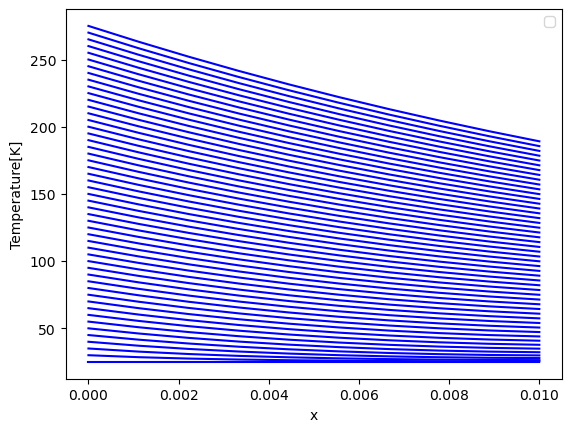

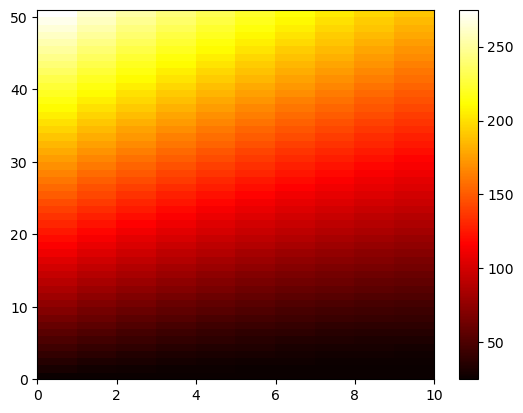

In [47]:
# Caso unidimensional implicito

import numpy as np
import matplotlib.pyplot as plt

#Input data
L = 0.01
s = 0
k = 1
T1bar = lambda t: 25 + 50 * t
T2inf = 25
hc = 40
alpha = 0.0001
T0 = 25
tend = 5 #Final time

#Discretization
N = 10
x = np.linspace(0, L, N)
dx = x[1] - x[0]
dt = 0.1
beta = alpha * dt / dx**2

# Construção das matrizes
A = np.diag(np.ones(N) * (2 * beta + 1))
A = A + np.diag(np.ones(N-1) * (-beta), 1)
A = A + np.diag(np.ones(N-1) * (-beta), -1) 
b_orig = (s * dt * alpha / k) * np.ones(N) 

# Boudary Conditions
A[0, :] = 0
A[0, 0] = 1

A[N-1, N-2] += -beta
A[N-1, N-1] += 2 * beta * dx * hc / k
b_orig [N-1] += 2 * beta * dx * hc * T2inf / k

Ainv = np.linalg.inv(A)

#Solving
Told = np.ones(N) * T0
t = dt
sol = []
sol.append(Told)
while(t < tend):
    b = Told + b_orig.copy()
    b[0] = T1bar(t)
    Tnew = Ainv @ b # @ é a multiplicação de matrizes em Python
    t += dt
    sol.append(Tnew)
    Told = Tnew
sol = np.array(sol)

Nt = int(tend / dt + 1)

#Plotting the solution
for k in range (Nt):
    plt.plot(x, sol[k,:], '-b')

plt.xlabel('x')
plt.ylabel('Temperature[K]')
plt.legend()
plt.show()

#plt.figure()
#plt.plot(sol[: , -1], '-r')

plt.pcolor(sol, cmap='hot')
plt.colorbar()

Fazer o 2D transiente e fazer tambem a formulação explícita